#**4. Exploratory Data Analysis (EDA)**

Notebook ini melakukan eksplorasi data untuk menjawab business questions yang telah ditetapkan
pada tahap Business Understanding.

In [ ]:
#load data
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

path = '/content/drive/MyDrive/Career Journey/Portofolio/1. retail sales analysis/data/cleaned/superstore_cleaned.csv'
df = pd.read_csv(path)
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df.head()

Mounted at /content/drive


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


#### **4.1 Univariate Analysis**

Melihat distribusi masing-masing variabel secara individual.

##### 4.1.1 Distribusi Numerik

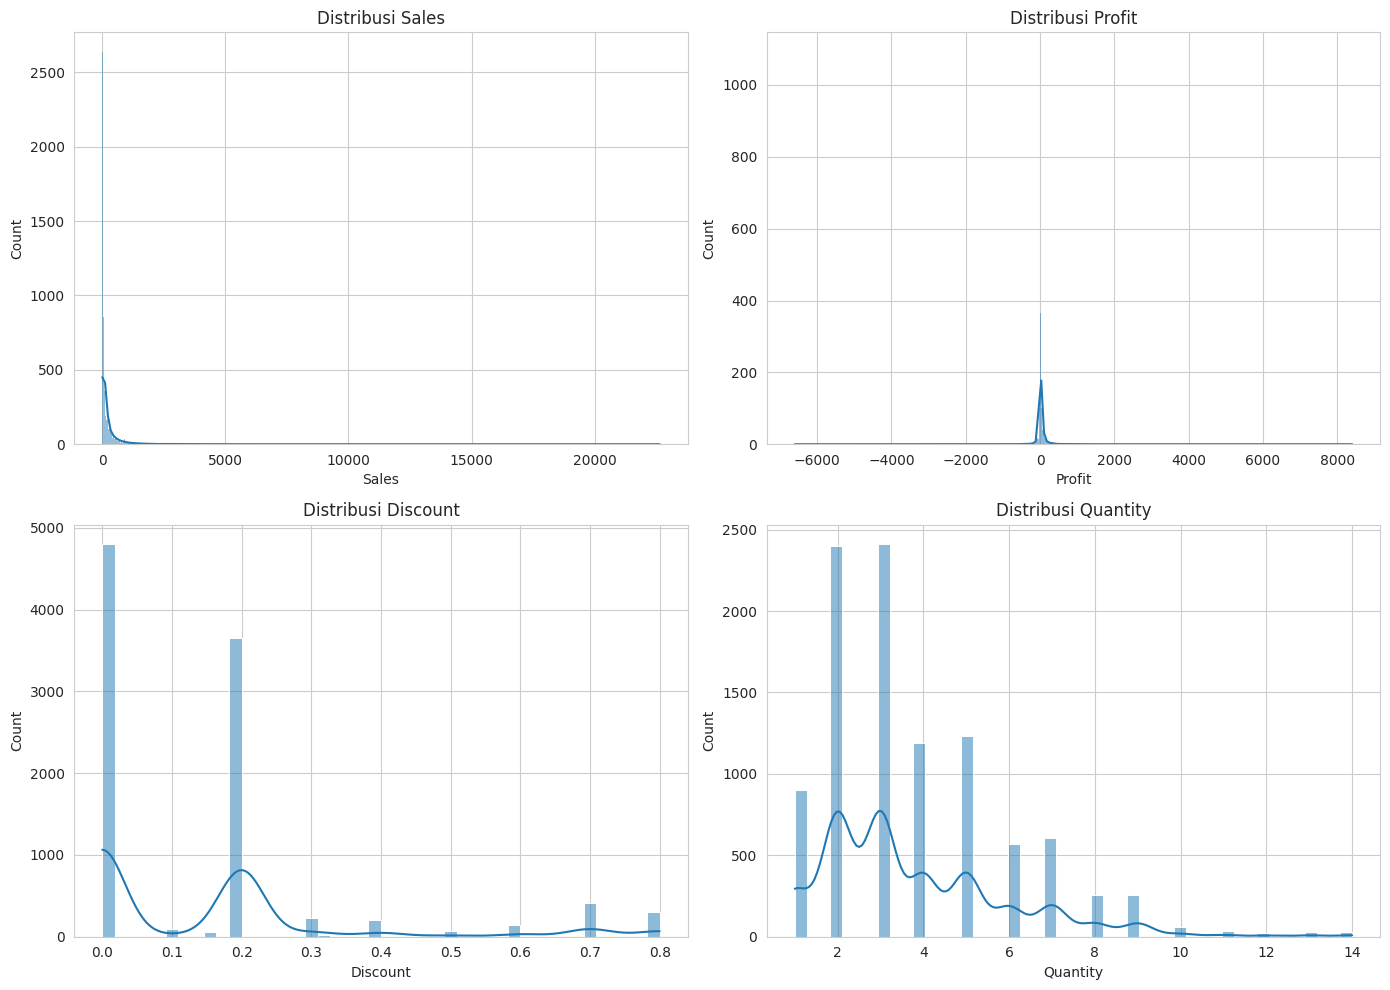

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cols = ['Sales', 'Profit', 'Discount', 'Quantity']

for i, col in enumerate(cols):
    ax = axes[i // 2, i % 2]
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f'Distribusi {col}')

plt.tight_layout()
plt.show()

##### 4.1.2 Distribusi Kategorikal

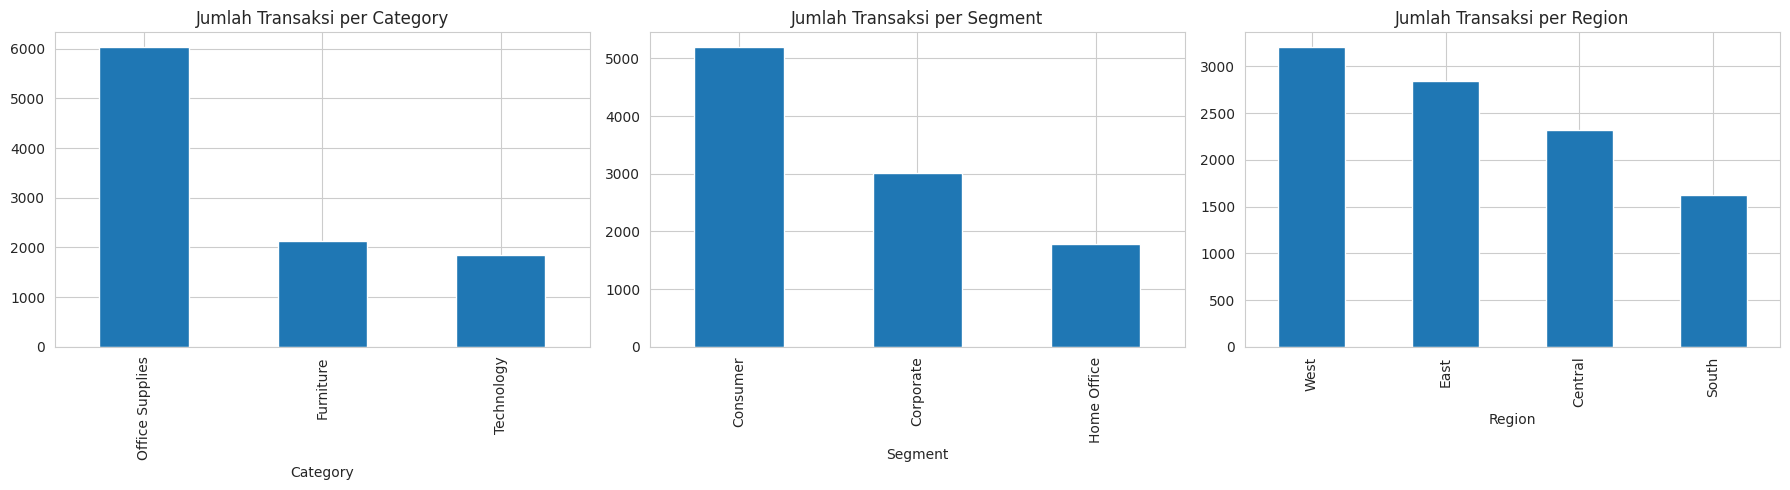

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df['Category'].value_counts().plot(kind='bar', ax=axes[0], title='Jumlah Transaksi per Category')
df['Segment'].value_counts().plot(kind='bar', ax=axes[1], title='Jumlah Transaksi per Segment')
df['Region'].value_counts().plot(kind='bar', ax=axes[2], title='Jumlah Transaksi per Region')

plt.tight_layout()
plt.show()

####**4.2 Bivariate Analysis**
Melihat hubungan antar dua variabel, difokuskan untuk menjawab business questions terkait
Product, Customer, Regional, dan Discount Analysis.

#####**4.2.1 Sales & Profit per Category**

                       Sales       Profit
Category                                 
Technology       836154.0330  145454.9481
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008


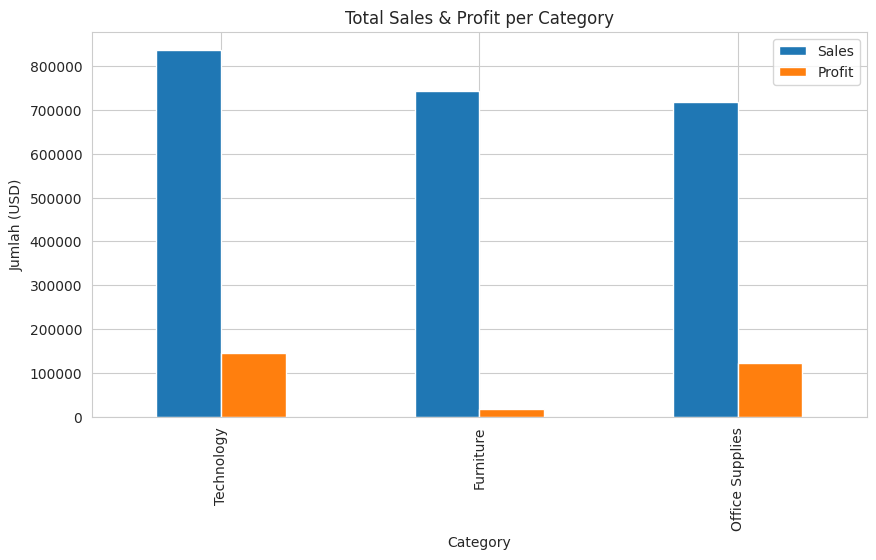

In [5]:
cat_summary = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
print(cat_summary)

cat_summary.plot(kind='bar', figsize=(10, 5), title='Total Sales & Profit per Category')
plt.ylabel('Jumlah (USD)')
plt.show()

#####**4.2.2 Profit per Sub-Category**

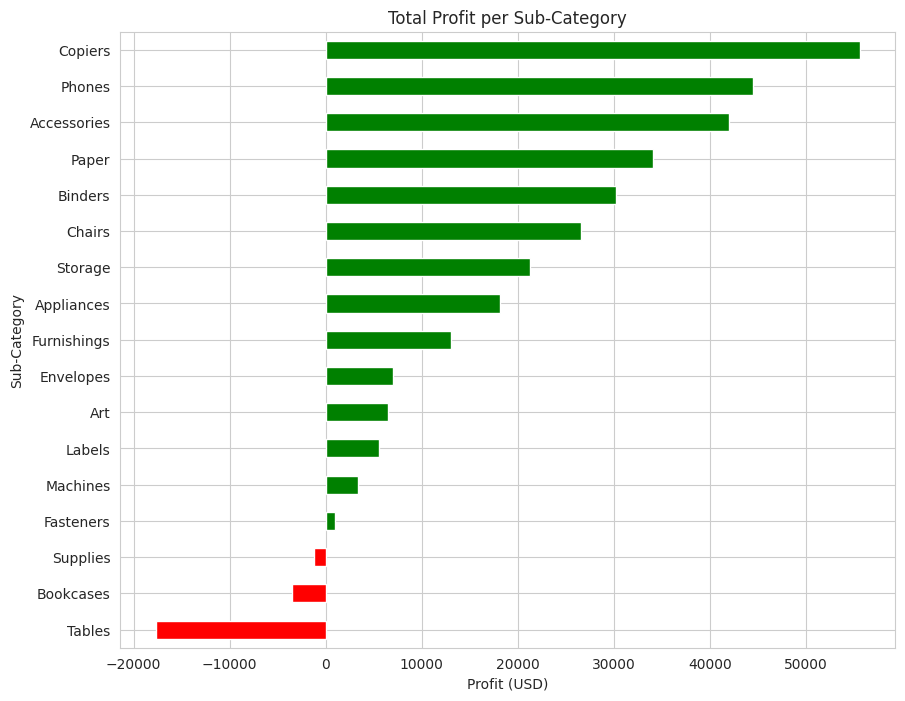

In [6]:
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

plt.figure(figsize=(10, 8))
subcat_profit.plot(kind='barh', color=subcat_profit.apply(lambda x: 'red' if x < 0 else 'green'))
plt.title('Total Profit per Sub-Category')
plt.xlabel('Profit (USD)')
plt.show()

#####**4.2.3 Segment vs Profit**

                    Sales       Profit
Segment                               
Consumer     1.161401e+06  134119.2092
Corporate    7.061464e+05   91979.1340
Home Office  4.296531e+05   60298.6785


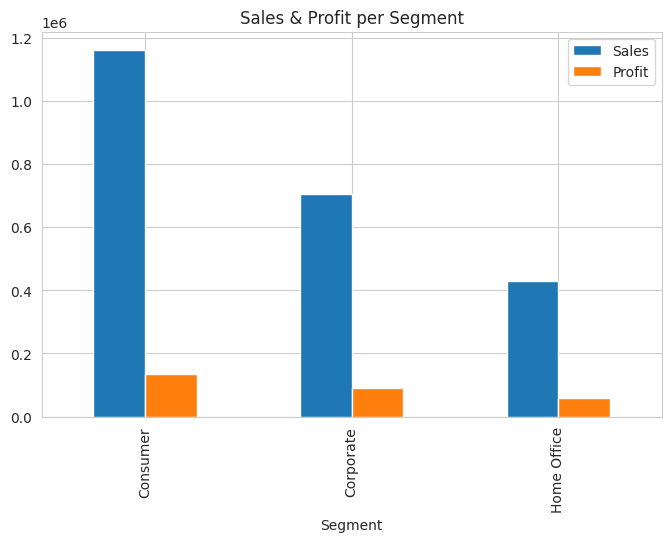

In [7]:
segment_summary = df.groupby('Segment')[['Sales', 'Profit']].sum().sort_values('Profit', ascending=False)
print(segment_summary)

segment_summary.plot(kind='bar', figsize=(8, 5), title='Sales & Profit per Segment')
plt.show()

#####**4.2.4 Top Customer**

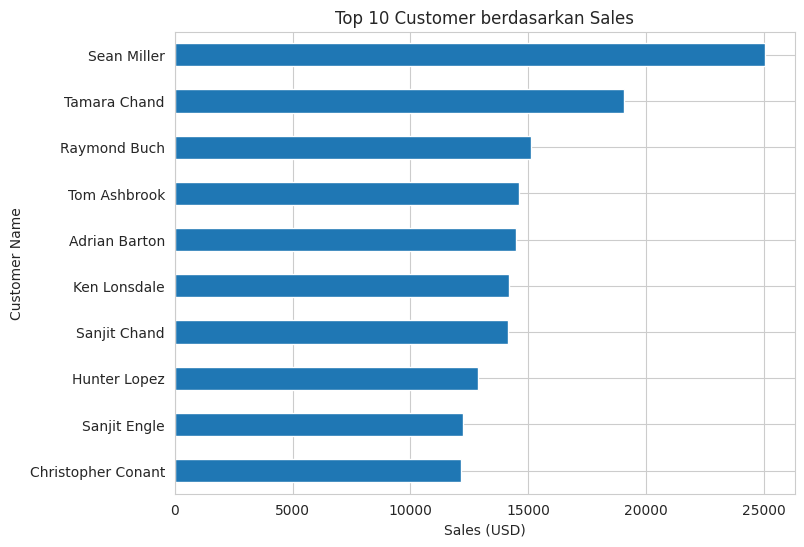

In [8]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_customers.plot(kind='barh', figsize=(8, 6), title='Top 10 Customer berdasarkan Sales')
plt.xlabel('Sales (USD)')
plt.gca().invert_yaxis()
plt.show()

#####**4.2.5 Region & State**

               Sales       Profit
Region                           
West     725457.8245  108418.4489
East     678781.2400   91522.7800
Central  501239.8908   39706.3625
South    391721.9050   46749.4303

10 State dengan Profit terendah:
State
Texas            -25729.3563
Ohio             -16971.3766
Pennsylvania     -15559.9603
Illinois         -12607.8870
North Carolina    -7490.9122
Colorado          -6527.8579
Tennessee         -5341.6936
Arizona           -3427.9246
Florida           -3399.3017
Oregon            -1190.4705
Name: Profit, dtype: float64


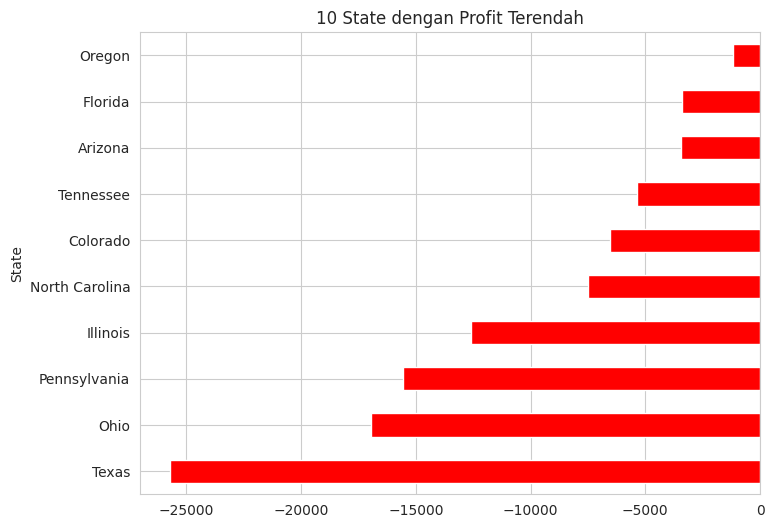

In [9]:
region_summary = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
print(region_summary)

state_profit = df.groupby('State')['Profit'].sum().sort_values().head(10)
print("\n10 State dengan Profit terendah:")
print(state_profit)

state_profit.plot(kind='barh', figsize=(8, 6), color='red', title='10 State dengan Profit Terendah')
plt.show()

#####**4.2.6 Discount vs Profit**

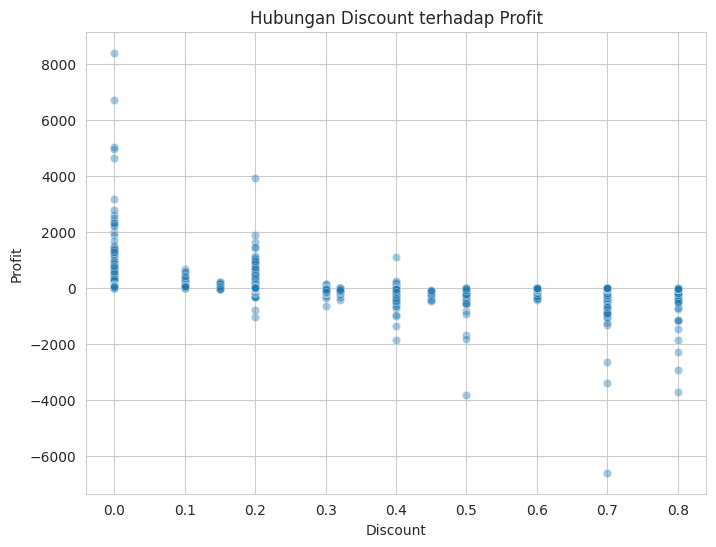

Korelasi Discount-Profit: -0.219


In [10]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.4)
plt.title('Hubungan Discount terhadap Profit')
plt.show()

correlation = df['Discount'].corr(df['Profit'])
print(f"Korelasi Discount-Profit: {correlation:.3f}")

### **4.3 Multivariate Analysis**

Melihat hubungan antar beberapa variabel sekaligus untuk temuan yang lebih dalam.

#####**4.3.1 Correlation Heatmap**

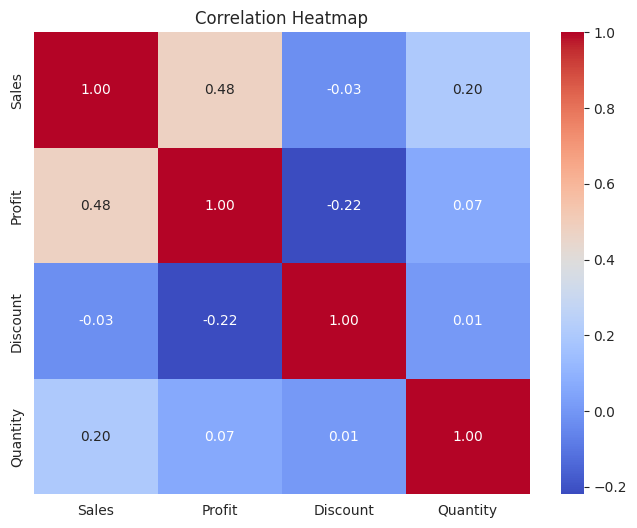

In [11]:
plt.figure(figsize=(8, 6))
numeric_cols = ['Sales', 'Profit', 'Discount', 'Quantity']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

#####**4.3.2 Discount vs Profit per Category**

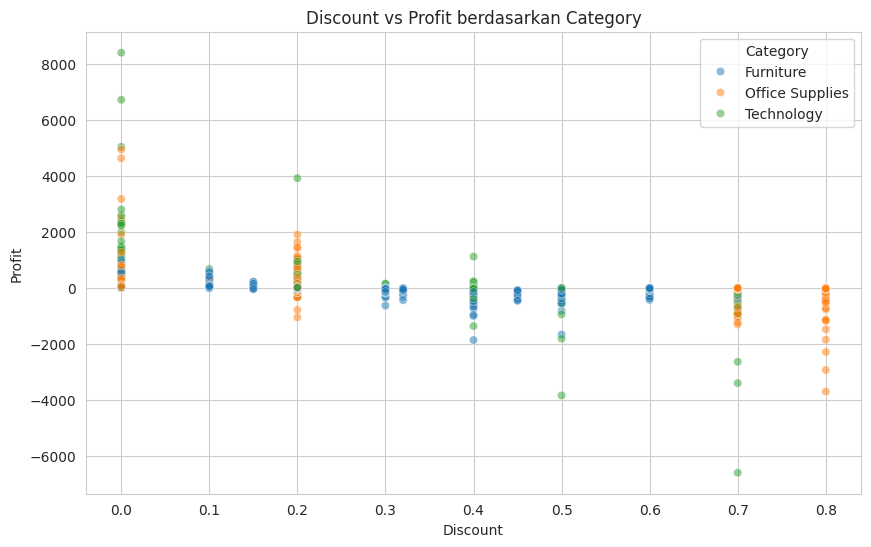

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.5)
plt.title('Discount vs Profit berdasarkan Category')
plt.show()